# Deep Learning Image Classification using CNN on CIFAR-10 Dataset

# Import Libraries

In [55]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Load Dataset

In [56]:


(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Check Dataset Shape

In [57]:
print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)

Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


# Normalize Images

In [58]:

x_train = x_train / 255.0
x_test = x_test / 255.0

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

# Define Class Names

In [59]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

# Display Sample Images

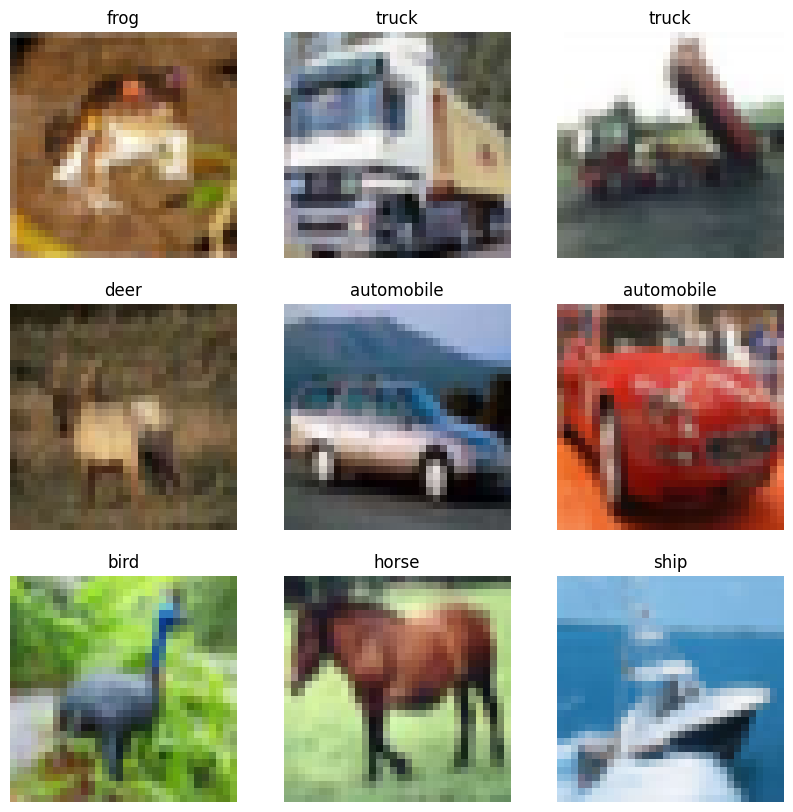

In [60]:
plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(x_train[i])

    plt.title(class_names[y_train[i][0]])

    plt.axis('off')

plt.show()

# Build CNN Model

In [62]:
model = models.Sequential()

# First Block
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.BatchNormalization())

model.add(layers.Conv2D(32, (3,3), activation='relu'))

model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Dropout(0.25))

# Second Block
model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.BatchNormalization())

model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Dropout(0.25))

# Third Block
model.add(layers.Conv2D(128, (3,3), activation='relu'))

model.add(layers.BatchNormalization())

model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Dropout(0.25))

# Flatten
model.add(layers.Flatten())

# Dense Layer
model.add(layers.Dense(128, activation='relu'))

model.add(layers.Dropout(0.5))

# Output Layer
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile Model

In [63]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# EarlyStopping

In [64]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3
)

# Train Model

In [65]:
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 251s 315ms/step - accuracy: 0.3006 - loss: 1.8965 - val_accuracy: 0.4207 - val_loss: 1.5891
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 248s 317ms/step - accuracy: 0.4371 - loss: 1.5397 - val_accuracy: 0.5058 - val_loss: 1.3727
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 246s 315ms/step - accuracy: 0.5084 - loss: 1.3745 - val_accuracy: 0.5139 - val_loss: 1.3852
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 249s 318ms/step - accuracy: 0.5470 - loss: 1.2820 - val_accuracy: 0.5907 - val_loss: 1.1741
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 249s 318ms/step - accuracy: 0.5790 - loss: 1.2031 - val_accuracy: 0.6108 - val_loss: 1.1122
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 249s 318ms/step - accuracy: 0.6011 - loss: 1.1443 - val_accuracy: 0.6309 - val_loss: 1.0444
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 260s 333ms/step - accuracy: 0.6220 - loss: 1.0969 - val_accuracy: 0.6233 - val_loss: 1.1134
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 251s 321ms/step - accuracy: 0.6290 -

# Evaluate Model

In [67]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("\nTest Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.7715 - loss: 0.6646

Test Accuracy: 0.7714999914169312


# Accuracy Graph

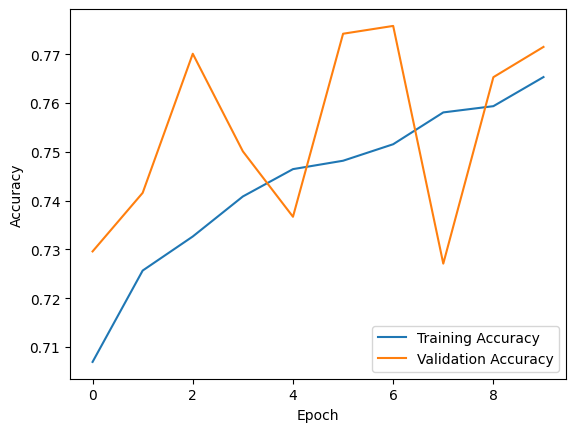

In [68]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()